In [147]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

In [148]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/shwetabh123/mall-customers/Mall_Customers.csv


In [149]:
df = pd.read_csv('/kaggle/input/datasets/shwetabh123/mall-customers/Mall_Customers.csv')

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [150]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (200, 5)

Column Names:
['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [151]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate Rows:
0


In [152]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


# Scikit-learn Machine Learning Workflow: Clustering

## Aim

To demonstrate a complete machine learning workflow using Scikit-learn, including data preprocessing, pipeline creation, model building, evaluation, visualization, and interpretation using K-Means, Hierarchical Clustering, and DBSCAN algorithms.

## Dataset

The Mall Customers dataset contains information about customers including age, annual income, and spending score. Clustering techniques are used to identify groups of customers with similar characteristics.

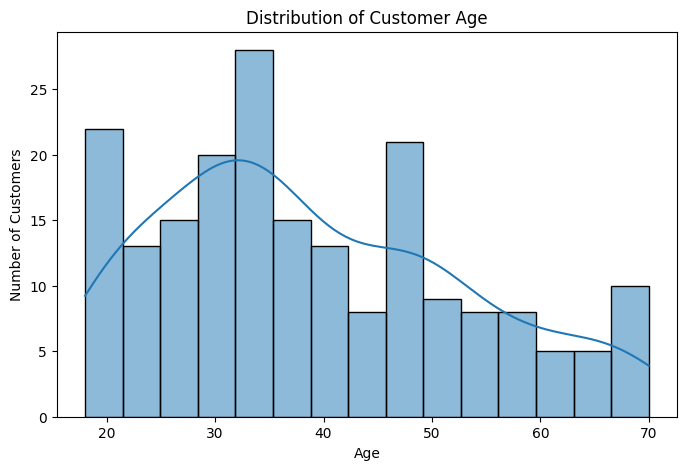

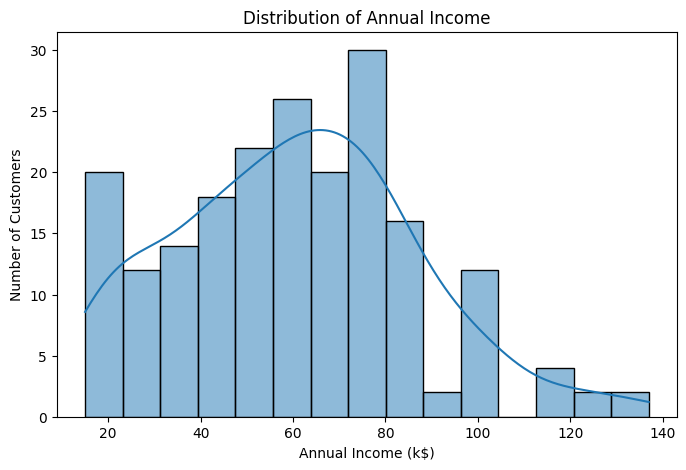

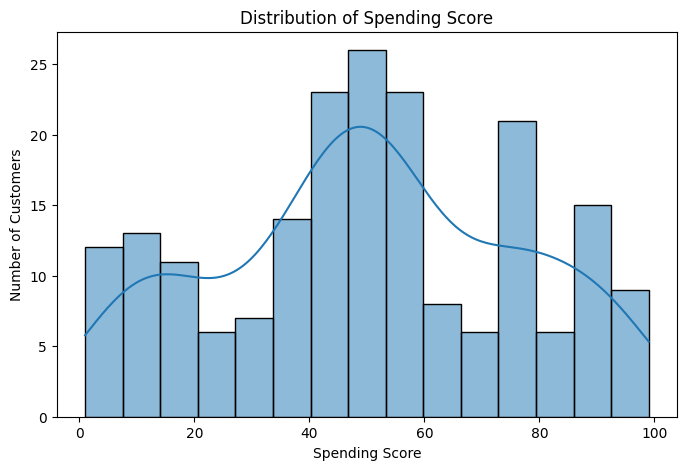

In [153]:
plt.figure(figsize=(8, 5))

sns.histplot(df['Age'], bins=15, kde=True)

plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Number of Customers')

plt.show()

plt.figure(figsize=(8, 5))

sns.histplot(df['Annual Income (k$)'], bins=15, kde=True)

plt.title('Distribution of Annual Income')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Number of Customers')

plt.show()

plt.figure(figsize=(8, 5))

sns.histplot(df['Spending Score (1-100)'], bins=15, kde=True)

plt.title('Distribution of Spending Score')
plt.xlabel('Spending Score')
plt.ylabel('Number of Customers')

plt.show()

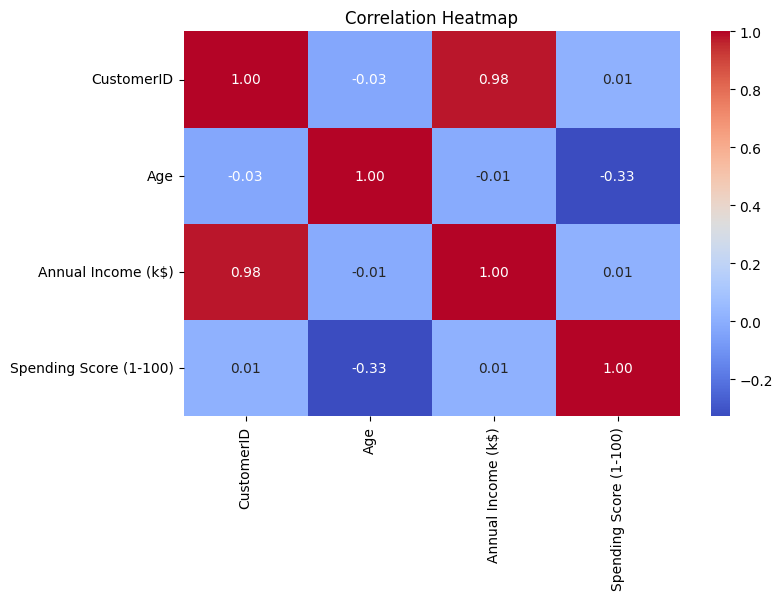

In [154]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8, 5))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

## Feature Selection

CustomerID is excluded because it is an identifier and does not represent customer characteristics.

The following numerical features are selected for clustering:

- Age
- Annual Income
- Spending Score

In [155]:
features = [
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]

X = df[features]

X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [156]:
print("Selected Features:")
print(features)

print("\nShape of Feature Dataset:")
print(X.shape)

print("\nFeature Statistics:")
print(X.describe())

Selected Features:
['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Shape of Feature Dataset:
(200, 3)

Feature Statistics:
              Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000          200.000000              200.000000
mean    38.850000           60.560000               50.200000
std     13.969007           26.264721               25.823522
min     18.000000           15.000000                1.000000
25%     28.750000           41.500000               34.750000
50%     36.000000           61.500000               50.000000
75%     49.000000           78.000000               73.000000
max     70.000000          137.000000               99.000000


## Data Preprocessing

The selected features have different numerical ranges. StandardScaler is used to standardize the features so that each feature contributes appropriately to the distance-based clustering algorithms.

In [157]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=features
)

X_scaled_df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


## Scikit-learn Pipeline

A Pipeline combines preprocessing and model training into a single workflow. This ensures that the same preprocessing steps are consistently applied before clustering.

In [158]:
kmeans_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(
        n_clusters=4,
        random_state=42,
        n_init=10
    ))
])

kmeans_pipeline

Pipeline(steps=[('scaler', StandardScaler()),
                ('kmeans', KMeans(n_clusters=4, n_init=10, random_state=42))])

In [159]:
inertia = []

for k in range(2, 11):

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('kmeans', KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        ))
    ])

    pipeline.fit(X)

    inertia.append(
        pipeline.named_steps['kmeans'].inertia_
    )
    

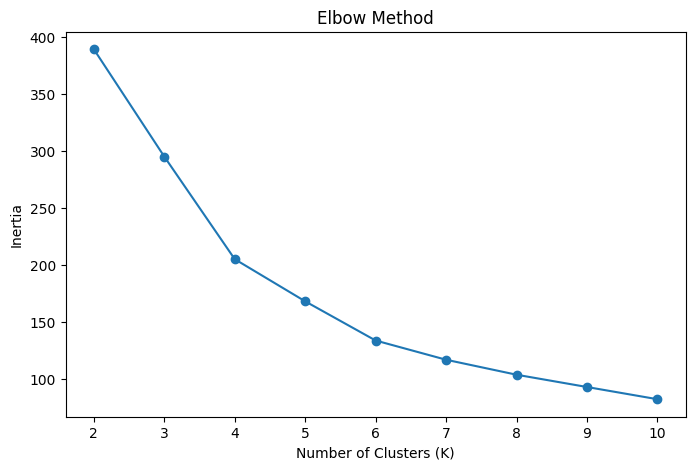

In [160]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.xticks(range(2, 11))

plt.show()

In [161]:
kmeans_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(
        n_clusters=4,
        random_state=42,
        n_init=10
    ))
])

kmeans_labels = kmeans_pipeline.fit_predict(X)

df['KMeans_Cluster'] = kmeans_labels

print("K-Means clustering completed.")

K-Means clustering completed.


In [162]:
print(df['KMeans_Cluster'].value_counts().sort_index())

KMeans_Cluster
0    65
1    40
2    57
3    38
Name: count, dtype: int64


In [163]:
kmeans_silhouette = silhouette_score(
    X_scaled,
    kmeans_labels
)

kmeans_db = davies_bouldin_score(
    X_scaled,
    kmeans_labels
)

print("K-Means Evaluation")
print("-------------------")
print("Silhouette Score:", round(kmeans_silhouette, 4))
print("Davies-Bouldin Index:", round(kmeans_db, 4))

K-Means Evaluation
-------------------
Silhouette Score: 0.404
Davies-Bouldin Index: 0.9308


In [164]:
hierarchical_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('hierarchical', AgglomerativeClustering(
        n_clusters=4,
        linkage='ward'
    ))
])

In [165]:
hierarchical_labels = hierarchical_pipeline.fit_predict(X)

df['Hierarchical_Cluster'] = hierarchical_labels

print("Hierarchical clustering completed.")

Hierarchical clustering completed.


In [166]:
hierarchical_silhouette = silhouette_score(
    X_scaled,
    hierarchical_labels
)

hierarchical_db = davies_bouldin_score(
    X_scaled,
    hierarchical_labels
)

print("Hierarchical Clustering Evaluation")
print("-----------------------------------")
print(
    "Silhouette Score:",
    round(hierarchical_silhouette, 4)
)

print(
    "Davies-Bouldin Index:",
    round(hierarchical_db, 4)
)

Hierarchical Clustering Evaluation
-----------------------------------
Silhouette Score: 0.3615
Davies-Bouldin Index: 1.0164


In [167]:
dbscan_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('dbscan', DBSCAN(
        eps=0.8,
        min_samples=5
    ))
])

In [168]:
dbscan_labels = dbscan_pipeline.fit_predict(X)

df['DBSCAN_Cluster'] = dbscan_labels

print("DBSCAN clustering completed.")

DBSCAN clustering completed.


In [169]:
unique_labels = np.unique(dbscan_labels)

print("DBSCAN Labels:")
print(unique_labels)

print("\nNumber of clusters excluding noise:",
      len(set(dbscan_labels) - {-1}))

print("\nNumber of noise points:",
      np.sum(dbscan_labels == -1))

DBSCAN Labels:
[-1  0]

Number of clusters excluding noise: 1

Number of noise points: 6


In [170]:
dbscan_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('dbscan', DBSCAN(eps=0.6, min_samples=5))
])

dbscan_labels = dbscan_pipeline.fit_predict(X)

df['DBSCAN_Cluster'] = dbscan_labels

unique_labels = np.unique(dbscan_labels)

print("DBSCAN Labels:")
print(unique_labels)

print("\nNumber of clusters excluding noise:",
      len(set(dbscan_labels) - {-1}))

print("\nNumber of noise points:",
      np.sum(dbscan_labels == -1))


DBSCAN Labels:
[-1  0  1]

Number of clusters excluding noise: 2

Number of noise points: 28


In [171]:
# Remove noise points for evaluation
mask = dbscan_labels != -1

X_scaled_dbscan = X_scaled[mask]
dbscan_labels_clean = dbscan_labels[mask]

dbscan_silhouette = silhouette_score(
    X_scaled_dbscan,
    dbscan_labels_clean
)

dbscan_db = davies_bouldin_score(
    X_scaled_dbscan,
    dbscan_labels_clean
)

print("DBSCAN Evaluation")
print("Silhouette Score:", round(dbscan_silhouette, 4))
print("Davies-Bouldin Index:", round(dbscan_db, 4))

DBSCAN Evaluation
Silhouette Score: 0.273
Davies-Bouldin Index: 1.0204


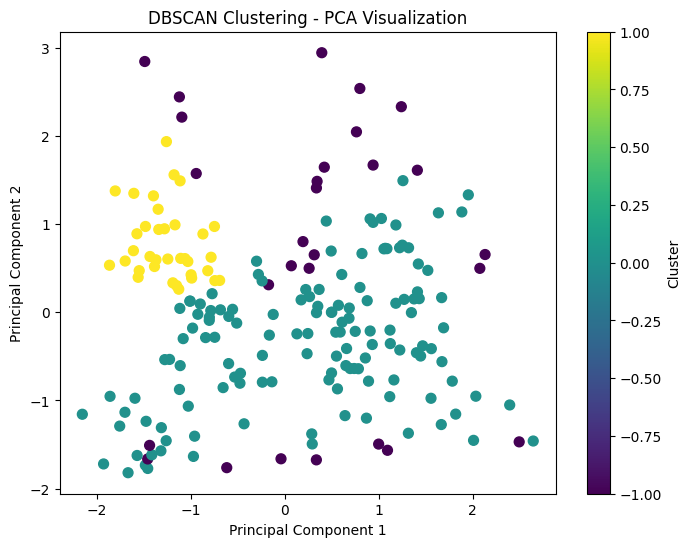

In [172]:
from sklearn.decomposition import PCA

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# DBSCAN visualization
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels,
    cmap='viridis',
    s=50
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('DBSCAN Clustering - PCA Visualization')
plt.colorbar(label='Cluster')
plt.show()

In [173]:
results = pd.DataFrame({
    'Algorithm': ['K-Means', 'Hierarchical', 'DBSCAN'],
    'Silhouette Score': [
        kmeans_silhouette,
        hierarchical_silhouette,
        dbscan_silhouette
    ],
    'Davies-Bouldin Index': [
        kmeans_db,
        hierarchical_db,
        dbscan_db
    ]
})

results

,Algorithm,Silhouette Score,Davies-Bouldin Index
0,K-Means,0.403958,0.930796
1,Hierarchical,0.361451,1.016382
2,DBSCAN,0.273047,1.020402


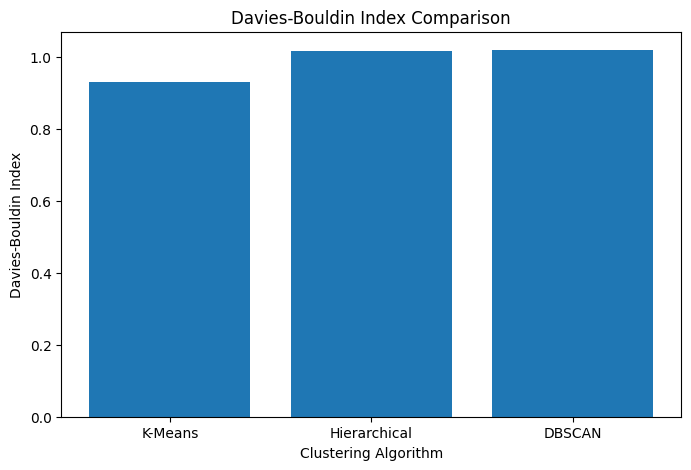

In [174]:
plt.figure(figsize=(8,5))

plt.bar(results['Algorithm'], results['Davies-Bouldin Index'])

plt.xlabel('Clustering Algorithm')
plt.ylabel('Davies-Bouldin Index')
plt.title('Davies-Bouldin Index Comparison')
plt.show()

In [175]:
kmeans_summary = df.groupby('KMeans_Cluster')[features].mean().round(2)

kmeans_summary

,Age,Annual Income (k$),Spending Score (1-100)
KMeans_Cluster,,,
0,53.98,47.71,39.97
1,32.88,86.10,81.53
2,25.44,40.00,60.30
3,39.37,86.50,19.58


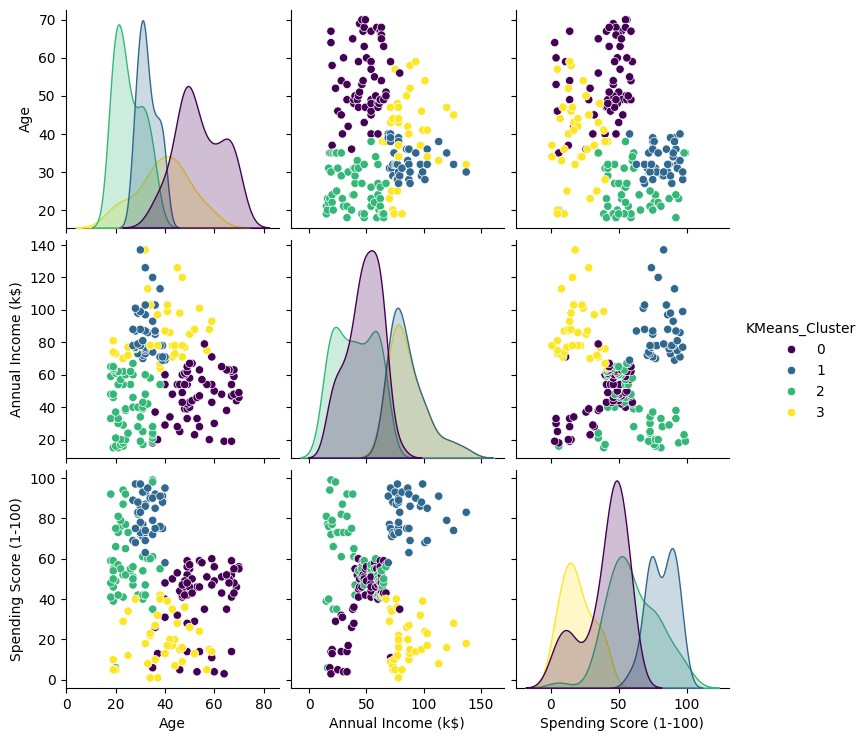

In [176]:
sns.pairplot(
    df,
    vars=features,
    hue='KMeans_Cluster',
    palette='viridis'
)

plt.show()

In [177]:
kmeans_summary = df.groupby('KMeans_Cluster')[features].mean().round(2)
kmeans_summary


,Age,Annual Income (k$),Spending Score (1-100)
KMeans_Cluster,,,
0,53.98,47.71,39.97
1,32.88,86.10,81.53
2,25.44,40.00,60.30
3,39.37,86.50,19.58


## Conclusion

In this practical, a complete machine-learning workflow was implemented using Scikit-learn. The Mall Customers dataset was loaded, explored, preprocessed, standardized, and analyzed using a Scikit-learn Pipeline.

Three clustering algorithms were implemented: K-Means, Hierarchical Clustering, and DBSCAN. Their performance was evaluated using Silhouette Score and Davies-Bouldin Index. K-Means produced a Silhouette Score of 0.4040 and a Davies-Bouldin Index of 0.9308. Hierarchical Clustering produced a Silhouette Score of 0.3615 and a Davies-Bouldin Index of 1.0164. DBSCAN produced two clusters with 28 noise points, with a noise-excluded Silhouette Score of 0.2730 and Davies-Bouldin Index of 1.0204.

PCA was also used to visualize the clustering results in two dimensions. The K-Means clusters were further interpreted using their average age, annual income, and spending score. This demonstrated how unsupervised machine learning can be used to identify meaningful customer segments from unlabeled data.